<a href="https://colab.research.google.com/github/jayrane260106/LOGIN-REGISTER-SYSTEM-MAJOR-PROJECT-1/blob/main/TASK_1_ML_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [ ]:
import zipfile
import pandas as pd

# Extract ZIP file
with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip", "r") as zip_ref:
    zip_ref.extractall("house_data")

# Load training dataset
df = pd.read_csv("house_data/train.csv")

# Display first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Load dataset
Explore dataset

In [ ]:
print(df.shape)
print(df.columns.tolist())

(1460, 81)
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea

 Explore dataset

In [ ]:
# Select only the required columns
data = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']]

# Display first 5 rows
data.head()

,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


Check missing values

In [ ]:
# Check missing values
print(data.isnull().sum())

GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64


In [ ]:
print(data.describe())

         GrLivArea  BedroomAbvGr     FullBath      SalePrice
count  1460.000000   1460.000000  1460.000000    1460.000000
mean   1515.463699      2.866438     1.565068  180921.195890
std     525.480383      0.815778     0.550916   79442.502883
min     334.000000      0.000000     0.000000   34900.000000
25%    1129.500000      2.000000     1.000000  129975.000000
50%    1464.000000      3.000000     2.000000  163000.000000
75%    1776.750000      3.000000     2.000000  214000.000000
max    5642.000000      8.000000     3.000000  755000.000000


In [ ]:
print(data.isnull().sum())

GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64


Select features

In [ ]:
# Input features
X = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

# Target variable
y = data['SalePrice']

print(X.head())
print(y.head())

   GrLivArea  BedroomAbvGr  FullBath
0       1710             3         2
1       1262             3         2
2       1786             3         2
3       1717             3         1
4       2198             4         2
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1168, 3)
Testing data shape: (292, 3)


Train Multiple Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Display regression coefficients

In [ ]:
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

Intercept: 52261.74862694461
GrLivArea : 104.0263070122644
BedroomAbvGr : -26655.16535734126
FullBath : 30014.324108956596


In [ ]:
print("Intercept:", model.intercept_)
print(model.coef_)

Intercept: 52261.74862694461
[   104.02630701 -26655.16535734  30014.32410896]


## Make predictions

In [ ]:
# Predict house prices for the test data
y_pred = model.predict(X_test)

# Display first 10 predictions
for actual, predicted in zip(y_test.head(10), y_pred[:10]):
    print(f"Actual: ${actual:,.2f} | Predicted: ${predicted:,.2f}")


Actual: $154,500.00 | Predicted: $113,410.67
Actual: $325,000.00 | Predicted: $305,081.88
Actual: $115,000.00 | Predicted: $135,904.79
Actual: $159,000.00 | Predicted: $205,424.68
Actual: $315,500.00 | Predicted: $227,502.68
Actual: $75,500.00 | Predicted: $121,157.48
Actual: $311,500.00 | Predicted: $205,577.98
Actual: $146,000.00 | Predicted: $183,787.20
Actual: $84,500.00 | Predicted: $121,157.48
Actual: $135,500.00 | Predicted: $147,219.22


Calculate MAE, MSE, RMSE and R²

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 35788.061292436294
Mean Squared Error (MSE): 2806426667.247853
Root Mean Squared Error (RMSE): 52975.71771338122
R² Score: 0.6341189942328371


ACTUAL VS PREDICTED GRAPH


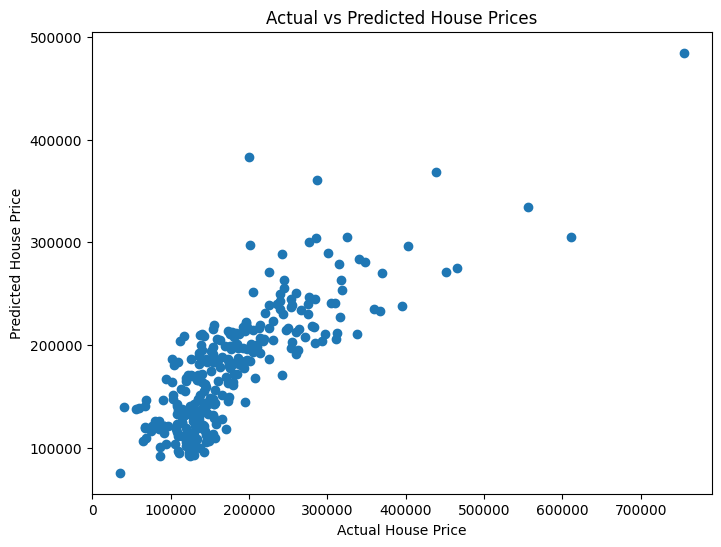

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

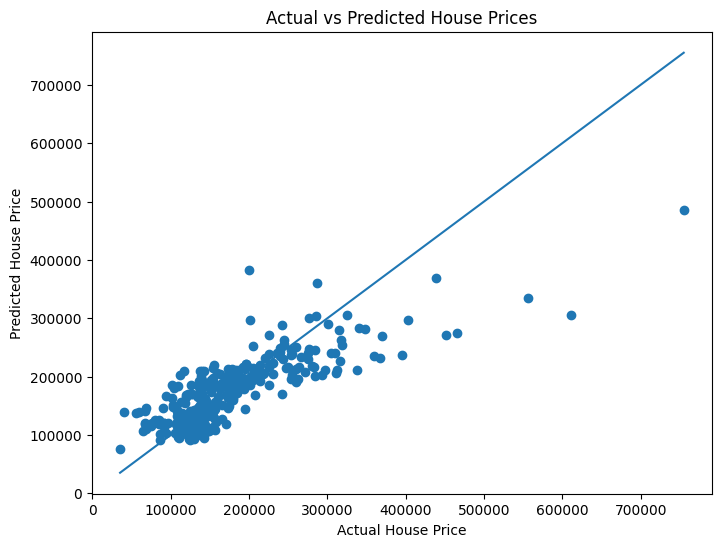

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

NEW HOUSE PREDICTION

In [ ]:
new_house = pd.DataFrame({
    'GrLivArea': [2000],
    'BedroomAbvGr': [3],
    'FullBath': [2]
})

predicted_price = model.predict(new_house)

print("Predicted House Price: ${:,.2f}".format(predicted_price[0]))

Predicted House Price: $240,377.51
